In [1]:
# IMPORT THE LIBRARIES
import math 
import math as m


import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns


import scipy.stats as stats


import warnings 
warnings.filterwarnings("ignore")


plt.figure(figsize = (10,7))


# split dataset
from sklearn.model_selection import train_test_split


# Scalling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

# Modelling
from sklearn.ensemble import GradientBoostingRegressor
gbm = GradientBoostingRegressor()


# Score Evalution 
from sklearn.metrics import r2_score, mean_squared_error

<Figure size 1000x700 with 0 Axes>

In [2]:
# Load Dataset 

df = pd.read_csv(r"C:\Users\Admin\Desktop\customer behaviour dataset\customer_shopping_behavior.csv")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
df.shape

(3900, 18)

# Univariate Analysis

In [4]:
df.select_dtypes(include = np.number).columns

num_cols = ['Age', 'Purchase Amount (USD)', 'Review Rating','Previous Purchases']

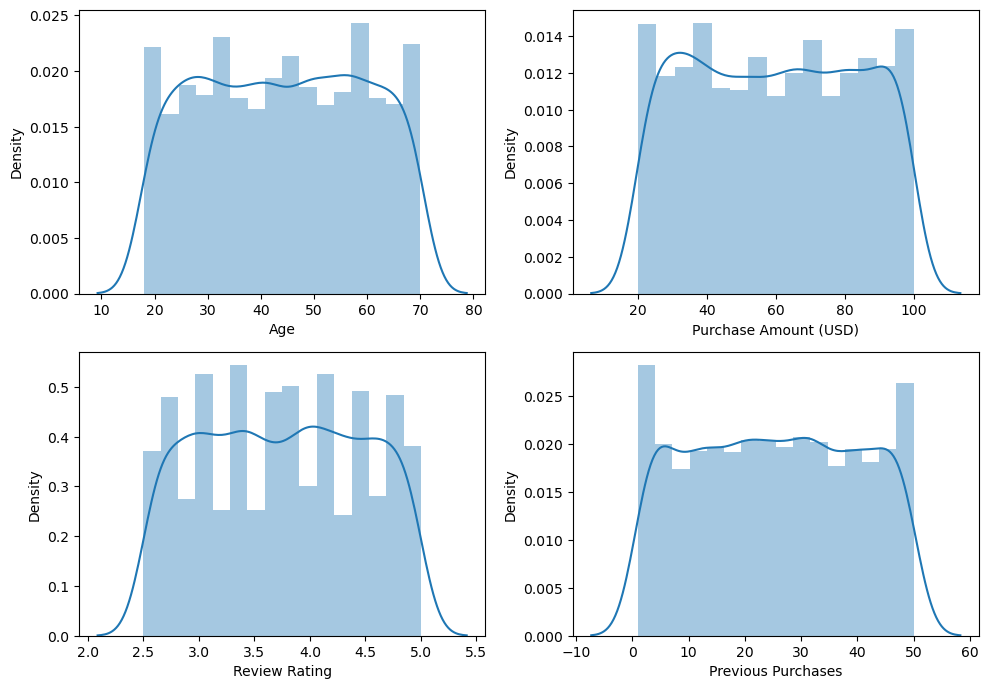

In [5]:
# numeric columns plots

nrows = 2
ncols = 2
iterator = 1


plt.figure(figsize = (10,7))
for i in num_cols:
    plt.subplot(nrows , ncols , iterator)
    sns.distplot(df.loc[:, i])
    iterator+=1

plt.tight_layout()
plt.show()

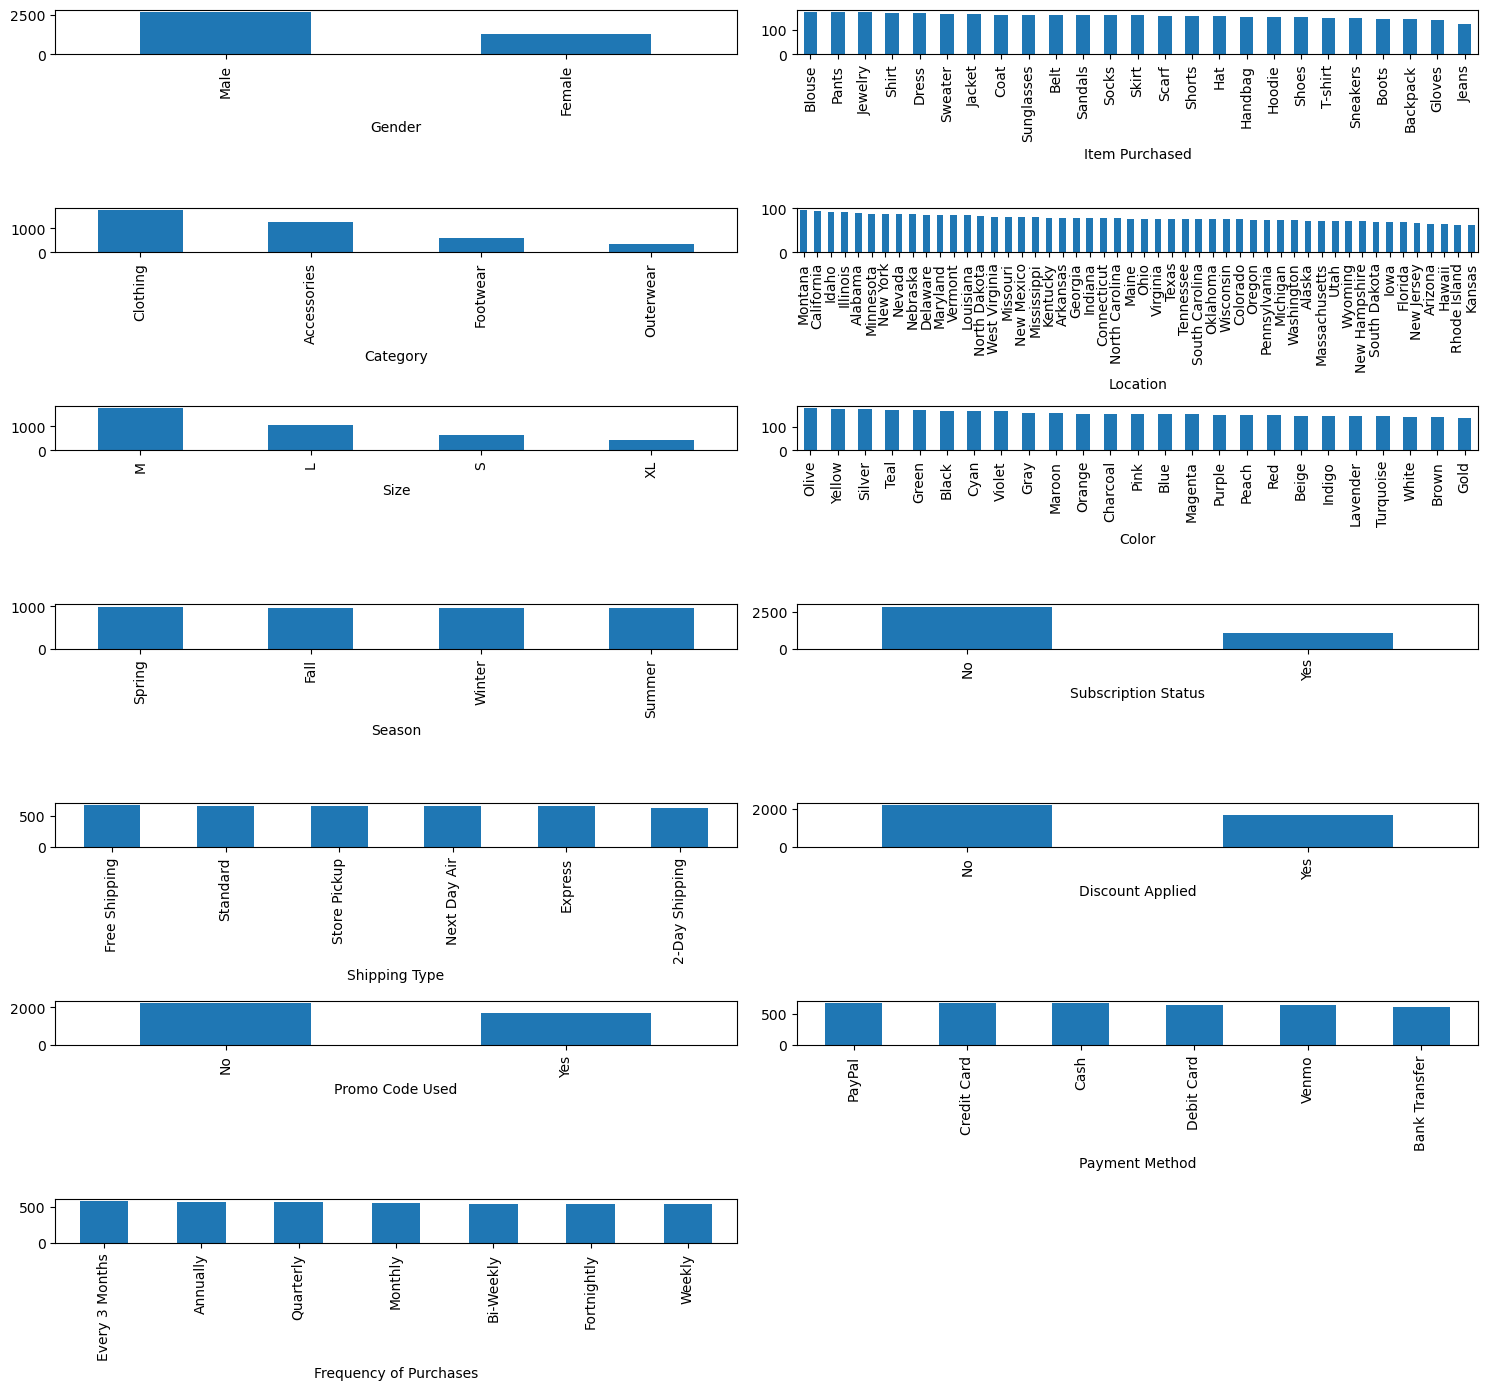

In [6]:
# categorical columns plot

cat_cols = df.select_dtypes(include = "object").columns

len(cat_cols)


nrows = 7
ncols = 2
iterator = 1


plt.figure(figsize= (15,14))
for i in cat_cols:
    plt.subplot(nrows, ncols, iterator )
    df.loc[:, i ].value_counts(ascending = False).plot(kind = "bar")
    iterator+=1


plt.tight_layout()
plt.show()

# Bivariate Analysis

In [7]:
# NUMBER_COLUMNS VS Purchase Amount (USD)

In [8]:
num_cols

['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']

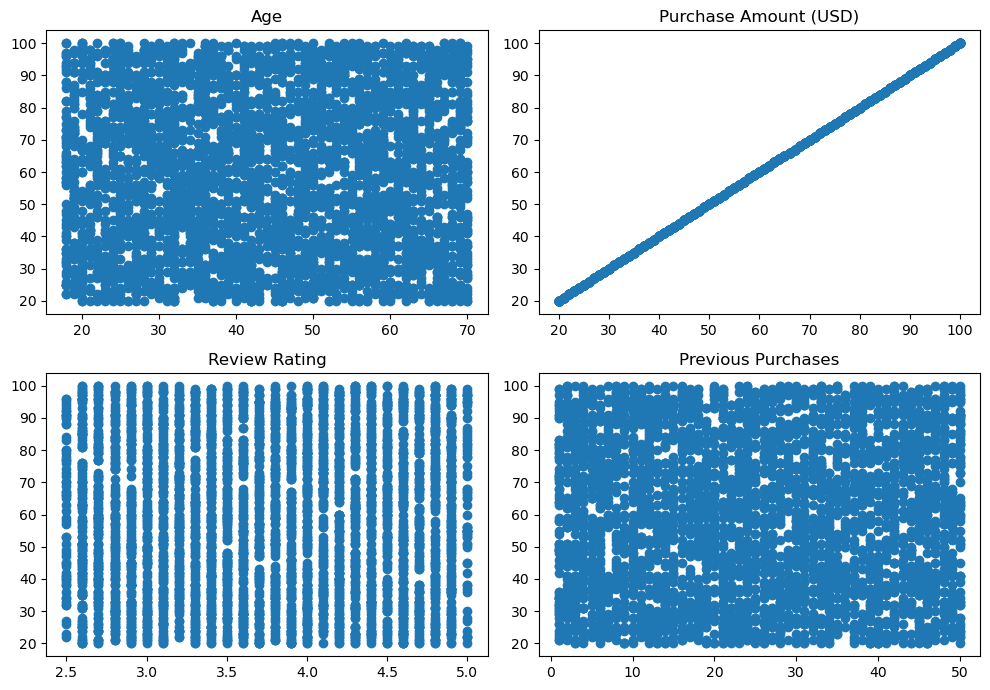

In [9]:
nrows = 2
ncols = 2
iterator = 1


plt.figure(figsize = (10, 7))
for i in num_cols:
    plt.subplot(nrows, ncols, iterator)
    plt.scatter(x = df.loc[: , i], y = df.loc[:,'Purchase Amount (USD)'])
    plt.title(i)
    iterator+=1

plt.tight_layout()
plt.show()

In [10]:
# CATEGORY VS Purchase Amount (USD)

In [11]:
cat_cols 

Index(['Gender', 'Item Purchased', 'Category', 'Location', 'Size', 'Color',
       'Season', 'Subscription Status', 'Shipping Type', 'Discount Applied',
       'Promo Code Used', 'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [12]:
len(cat_cols)

13

# MISSING VALUE

In [13]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [14]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


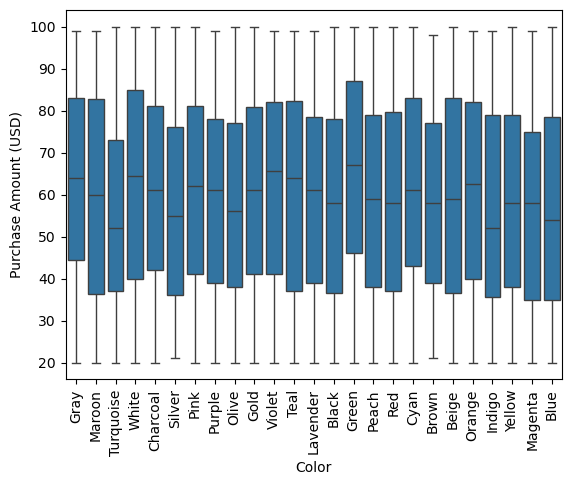

'Olive'

In [15]:
# Color

sns.boxplot(x = df["Color"] , y = df["Purchase Amount (USD)"])
plt.xticks(rotation = 90)
plt.show()
df["Color"].mode()[0]

In [16]:
df["Color"] = df["Color"].fillna(df["Color"].mode()[0])

In [17]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [18]:
# Review Rating 

df["Review Rating"] = df.groupby("Category")["Review Rating"].transform(lambda x: x.fillna(x.median))

In [19]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [20]:
# cahnging columns in lower case
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ","_")
df = df.rename(columns = {'purchase_amount_(usd)':'purchase_amount'})

In [21]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
item_purchased            0
category                  0
purchase_amount           0
location                  0
size                      0
color                     0
season                    0
review_rating             0
subscription_status       0
shipping_type             0
discount_applied          0
promo_code_used           0
previous_purchases        0
payment_method            0
frequency_of_purchases    0
dtype: int64

# FEATURE ENGINEERING

In [22]:
# Create a column age_group

labels = ["Young_Adult", "Adult", "Middle_Age", "Senior"]               # cut() → numbers/range equally divide karta hai
df["age_group"] = pd.qcut(df["age"], q = 4, labels = labels)            # qcut() → rows equally divide karta hai

In [23]:
pd.qcut(df["age"], q=4).value_counts()

age
(17.999, 31.0]    1028
(44.0, 57.0]       986
(57.0, 70.0]       944
(31.0, 44.0]       942
Name: count, dtype: int64

In [24]:
df[["age", "age_group"]].head(10)

,age,age_group
0,55,Middle_Age
1,19,Young_Adult
2,50,Middle_Age
3,21,Young_Adult
4,45,Middle_Age
5,46,Middle_Age
6,63,Senior
7,27,Young_Adult
8,26,Young_Adult
9,57,Middle_Age


In [25]:
# create a column purchase_frequency_days


frequency_of_purchases = {"Every 3 Months" : 90,
                          "Annually" : 365,
                          "Quarterly" : 90,
                          "Monthly" : 30,
                          "Bi-Weekly" : 14,
                          "Fortnightly" : 14,
                          "Weekly" : 7 }

df["purchase_frequency_days"] = df["frequency_of_purchases"].map(frequency_of_purchases)

In [26]:
df[["frequency_of_purchases","purchase_frequency_days"]]

,frequency_of_purchases,purchase_frequency_days
0,Fortnightly,14
1,Fortnightly,14
2,Weekly,7
3,Weekly,7
4,Annually,365
...,...,...
3895,Weekly,7
3896,Bi-Weekly,14
3897,Quarterly,90
3898,Weekly,7


In [27]:
# checking both have same information

df[["discount_applied","promo_code_used"]]

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
...,...,...
3895,No,No
3896,No,No
3897,No,No
3898,No,No


In [28]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases', 'age_group',
       'purchase_frequency_days'],
      dtype='object')

In [29]:
# FE on Location column

NORTH = ["Maine", "Massachusetts", "Rhode Island", "New Hampshire","New York", "Vermont", "Connecticut", "New Jersey", "Pennsylvania"]

SOUTH = ["Texas", "Florida", "Alabama", "Mississippi", "Louisiana","Georgia", "North Carolina", "South Carolina", "Tennessee","Arkansas", "Virginia", "West Virginia"]

WEST = ["California", "Oregon", "Washington", "Nevada", "Arizona","Utah", "Colorado", "Idaho", "Montana", "Wyoming", "Alaska", "Hawaii"]

MIDWEST = ["Illinois", "Indiana", "Ohio", "Michigan", "Wisconsin","Minnesota", "Iowa", "Missouri", "Kansas", "Nebraska","North Dakota", "South Dakota"]

CENTRAL = ["Oklahoma", "New Mexico", "Kentucky"]


def loc(x):
    if x in NORTH:
        return "NORTH"
    elif x in SOUTH:
        return "SOUTH"
    elif x in WEST:
        return "WEST"
    elif x in MIDWEST:
        return "MIDWEST"
    else:
        return "CENTRAL"


df["location"] = df["location"].apply(loc)

In [30]:
# FE on color column

neutral = ['Black','White','Gray','Beige','Brown','Silver']
warm = ['Red','Orange','Yellow','Pink','Peach','Gold','Maroon']
cool = ['Blue','Green','Cyan','Teal','Indigo','Purple','Violet']


def color_group(color):
    if color in neutral:
        return "neutral"
    elif color in warm:
        return "warm"
    else:
        return "cool"
    

df["color"] = df["color"].apply(color_group)

In [31]:
df

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days
0,1,55,Male,Blouse,Clothing,53,CENTRAL,L,neutral,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,Middle_Age,14
1,2,19,Male,Sweater,Clothing,64,NORTH,L,warm,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,Young_Adult,14
2,3,50,Male,Jeans,Clothing,73,NORTH,S,warm,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Middle_Age,7
3,4,21,Male,Sandals,Footwear,90,NORTH,M,warm,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,Young_Adult,7
4,5,45,Male,Blouse,Clothing,49,WEST,M,cool,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,Middle_Age,365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,SOUTH,L,cool,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly,Adult,7
3896,3897,52,Female,Backpack,Accessories,49,MIDWEST,L,neutral,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly,Middle_Age,14
3897,3898,46,Female,Belt,Accessories,33,NORTH,L,cool,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly,Middle_Age,90
3898,3899,44,Female,Shoes,Footwear,77,MIDWEST,S,neutral,Summer,3.8,No,Express,No,No,24,Venmo,Weekly,Adult,7


In [32]:
# submission for SQL analysis

df.to_csv("processed_data.csv", index=False)

In [33]:
cd

C:\Users\Admin


# Outliers Analysis & Removal

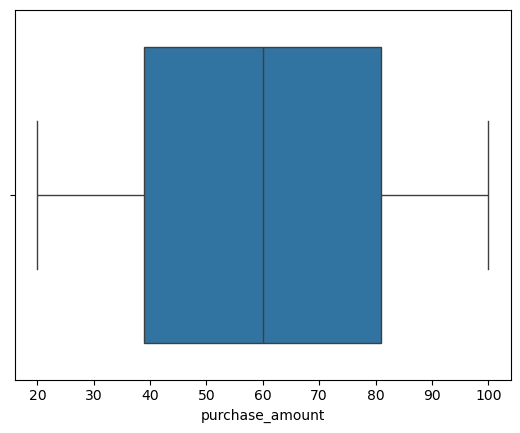

In [34]:
sns.boxplot(x = df["purchase_amount"])
plt.show()

In [35]:
# No need to do outliers removal beacause there are no outliers to remove

# Drop unnecessary columns

In [36]:
# Removing "discount_applied" column beacuse of same data in both column
(df["discount_applied"] == 	df["promo_code_used"]).all()
df = df.drop(columns = ["discount_applied"])

In [37]:
# droped customer_id because of all unique values
df = df.drop("customer_id", axis = 1)

In [38]:
# drop this column because creted a column which is relate this 
df = df.drop(columns = "frequency_of_purchases")

# Train & Test Split

In [39]:
df.head()

,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,promo_code_used,previous_purchases,payment_method,age_group,purchase_frequency_days
0,55,Male,Blouse,Clothing,53,CENTRAL,L,neutral,Winter,3.1,Yes,Express,Yes,14,Venmo,Middle_Age,14
1,19,Male,Sweater,Clothing,64,NORTH,L,warm,Winter,3.1,Yes,Express,Yes,2,Cash,Young_Adult,14
2,50,Male,Jeans,Clothing,73,NORTH,S,warm,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Middle_Age,7
3,21,Male,Sandals,Footwear,90,NORTH,M,warm,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Young_Adult,7
4,45,Male,Blouse,Clothing,49,WEST,M,cool,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Middle_Age,365


In [40]:
# Target and features

x = df.drop(columns = "purchase_amount", axis = 1)
y = df["purchase_amount"]


# spliting

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y , test_size = 0.2, random_state = 42)

In [41]:
(x_train.columns == x_test.columns)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True])

# Scalling

In [42]:
# StandardScaler (z score transformation)

In [43]:
df.head()

,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,promo_code_used,previous_purchases,payment_method,age_group,purchase_frequency_days
0,55,Male,Blouse,Clothing,53,CENTRAL,L,neutral,Winter,3.1,Yes,Express,Yes,14,Venmo,Middle_Age,14
1,19,Male,Sweater,Clothing,64,NORTH,L,warm,Winter,3.1,Yes,Express,Yes,2,Cash,Young_Adult,14
2,50,Male,Jeans,Clothing,73,NORTH,S,warm,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Middle_Age,7
3,21,Male,Sandals,Footwear,90,NORTH,M,warm,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Young_Adult,7
4,45,Male,Blouse,Clothing,49,WEST,M,cool,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Middle_Age,365


In [44]:
num_cols = x_train.select_dtypes(include = np.number).columns
num_cols

Index(['age', 'previous_purchases', 'purchase_frequency_days'], dtype='object')

In [45]:
x_train.loc[: , num_cols].describe()

,age,previous_purchases,purchase_frequency_days
count,3120.000000,3120.000000,3120.000000
mean,44.042949,25.402564,88.153205
std,15.210379,14.520953,118.490472
min,18.000000,1.000000,7.000000
25%,31.000000,13.000000,14.000000
50%,44.000000,25.000000,30.000000
75%,57.000000,38.000000,90.000000
max,70.000000,50.000000,365.000000


In [46]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [47]:
# scalling on x_train 
x_train[num_cols] = sc.fit_transform(x_train.loc[:, num_cols])


# scalling on x_test
x_test[num_cols] = sc.transform(x_test.loc[: , num_cols])

In [48]:
(x_train.columns == x_test.columns)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True])

# Transformation (if needed)

In [49]:
x_train.loc[:, num_cols].skew()

age                       -0.009526
previous_purchases        -0.007075
purchase_frequency_days    1.714346
dtype: float64

In [50]:
x_test.loc[:, num_cols].skew()

age                        0.006274
previous_purchases         0.044968
purchase_frequency_days    1.618059
dtype: float64

In [51]:
# No need to transformation beacause all the skweness are balanced

# Categorical Encoding 

In [52]:
x_train 

,age,gender,item_purchased,category,location,size,color,season,review_rating,subscription_status,shipping_type,promo_code_used,previous_purchases,payment_method,age_group,purchase_frequency_days
247,-0.989151,Male,Sweater,Clothing,WEST,XL,neutral,Spring,4.4,Yes,Standard,Yes,-0.785375,Debit Card,Young_Adult,-0.685002
2591,-0.265845,Male,Jacket,Outerwear,CENTRAL,S,cool,Spring,3.3,No,Express,No,1.005428,Cash,Adult,0.015589
1822,1.443789,Male,Shirt,Clothing,NORTH,S,cool,Summer,4.4,No,Standard,No,-1.474145,Cash,Senior,2.336822
3483,-1.646702,Female,Hoodie,Clothing,SOUTH,L,neutral,Winter,3.9,No,Express,No,-0.303236,Credit Card,Young_Adult,0.015589
2771,0.917748,Female,Jacket,Outerwear,CENTRAL,S,neutral,Summer,3.1,No,2-Day Shipping,No,-0.923129,Bank Transfer,Senior,-0.625916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,1.509544,Male,Jewelry,Accessories,CENTRAL,M,cool,Summer,3.9,No,Standard,Yes,0.316658,PayPal,Senior,-0.625916
1294,-1.120661,Male,Shirt,Clothing,SOUTH,M,neutral,Summer,4.5,No,Standard,Yes,-0.303236,Cash,Young_Adult,0.015589
860,-1.186416,Male,Shoes,Footwear,SOUTH,M,warm,Spring,4.1,Yes,Standard,Yes,-1.543022,Cash,Young_Adult,-0.490862
3507,0.128686,Female,Handbag,Accessories,WEST,S,cool,Spring,4.2,No,Store Pickup,No,0.523289,Credit Card,Middle_Age,0.015589


In [53]:
x_test

,age,gender,item_purchased,category,location,size,color,season,review_rating,subscription_status,shipping_type,promo_code_used,previous_purchases,payment_method,age_group,purchase_frequency_days
839,0.260196,Male,Shirt,Clothing,MIDWEST,L,cool,Spring,2.6,Yes,Free Shipping,Yes,-1.060883,Debit Card,Middle_Age,0.015589
1717,-0.989151,Male,Hoodie,Clothing,WEST,L,warm,Summer,2.9,No,Express,No,-0.647621,Debit Card,Young_Adult,-0.625916
321,-0.200089,Male,Sneakers,Footwear,NORTH,L,warm,Summer,4.7,Yes,Free Shipping,Yes,1.556445,Debit Card,Adult,0.015589
3187,1.509544,Female,Blouse,Clothing,SOUTH,L,cool,Winter,3.2,No,Free Shipping,No,0.178904,Debit Card,Senior,-0.685002
2269,0.325951,Male,Skirt,Clothing,CENTRAL,M,warm,Fall,4.4,No,Store Pickup,No,0.110027,Credit Card,Middle_Age,2.336822
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1393,0.128686,Male,Gloves,Accessories,WEST,L,warm,Spring,3.9,No,Express,Yes,-0.785375,PayPal,Middle_Age,-0.625916
3751,-0.528865,Female,Jewelry,Accessories,SOUTH,S,neutral,Fall,4.2,No,Free Shipping,No,-1.198637,Credit Card,Adult,0.015589
2696,0.851992,Female,Coat,Outerwear,MIDWEST,M,neutral,Spring,4.7,No,Free Shipping,No,-0.923129,Debit Card,Middle_Age,-0.490862
2384,-1.317926,Male,Blouse,Clothing,SOUTH,L,cool,Winter,3.3,No,2-Day Shipping,No,1.005428,PayPal,Young_Adult,0.015589


In [54]:
# Encoding on x_train
x_train = pd.get_dummies(x_train,drop_first = True)

# Encoding on x_test
x_test = pd.get_dummies(x_test, drop_first = True)


x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

# Modelling

In [55]:
from sklearn.ensemble import GradientBoostingRegressor
gbm = GradientBoostingRegressor()

In [56]:
pred = gbm.fit(x_train, y_train).predict(x_test)
pred

array([60.55814045, 55.58014166, 60.55341365, 57.17730127, 62.8472345 ,
       60.12513463, 62.11913108, 63.82947881, 60.86696412, 60.11350127,
       58.06138323, 59.20571169, 63.3732126 , 59.34071104, 59.7411617 ,
       54.89352208, 63.61341531, 54.59985869, 63.76563898, 61.85904421,
       63.28056019, 60.02127533, 57.03187847, 63.78973076, 61.15902491,
       59.99540599, 60.52507562, 59.54016407, 61.91855735, 63.94097494,
       59.2201699 , 67.80730728, 60.81446307, 55.80816004, 61.88025563,
       60.55371755, 58.77008759, 59.37929049, 57.32215137, 56.40265528,
       56.04448804, 59.87074401, 56.92073244, 54.17291195, 57.71387728,
       58.49038271, 60.51583431, 57.89400291, 55.48190405, 56.83917079,
       62.94476165, 69.68161394, 55.84735195, 64.13155722, 58.69235008,
       71.14431317, 67.87259099, 59.12507861, 70.41762058, 63.76851868,
       62.31555486, 63.69458235, 59.35810808, 54.79021353, 62.4513002 ,
       65.62438905, 55.64902445, 60.32855191, 63.92708421, 60.65

# Score Evaluation

In [57]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE:", rmse)

RMSE: 24.11452200765815


# Summary

Performed Customer Behavior Analysis by cleaning and preprocessing the data, handling missing values, and applying feature engineering techniques. 
Conducted EDA to identify customer purchase patterns, spending trends, and preferences across categories, seasons, subscriptions, and payment methods.
Applied encoding and scaling for data preparation and built a Gradient Boosting Model (GBM) to predict Purchase Amount (USD) based on customer
behavior features.